<a href="https://www.kaggle.com/code/yashbrahmankar95/ford-car-price-prediction-linear-regression?scriptVersionId=316914402" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


# 🚗 Ford Car Price Prediction - Linear Regression

## 📌 Project Overview
This project analyzes the Ford dataset and builds a Linear Regression model to predict car prices.

## 📊 Workflow
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training

## 📈 Results
- R² Score: 0.91

## 🔍 Key Insights
- Newer cars have higher prices
- Mileage negatively affects price
- Engine size influences price

In [2]:
import seaborn as sn
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.shape

(17966, 9)

In [5]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [7]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

# EDA

<Axes: xlabel='price', ylabel='Count'>

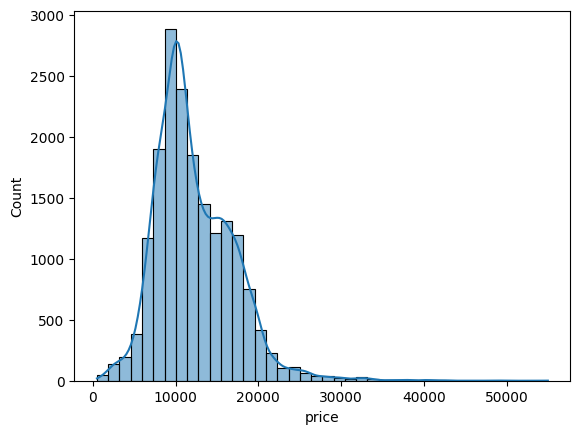

In [8]:
sn.histplot(df['price'], kde = True , bins = 40 )

In [9]:
corr = df.corr(numeric_only = True )
corr

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.636009,-0.707818,0.298506,-0.022967,-0.137311
price,0.636009,1.000000,-0.530659,0.406857,-0.346419,0.411178
mileage,-0.707818,-0.530659,1.000000,-0.260451,0.120075,0.215035
tax,0.298506,0.406857,-0.260451,1.000000,-0.502980,0.184363
mpg,-0.022967,-0.346419,0.120075,-0.502980,1.000000,-0.260521
engineSize,-0.137311,0.411178,0.215035,0.184363,-0.260521,1.000000


<Axes: >

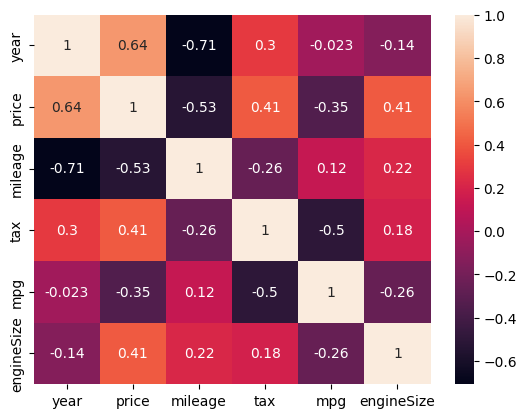

In [10]:
# correalation 

sn.heatmap(df.corr(numeric_only  = True) , annot = True)

In [11]:
corr_values = corr.values.flatten() #  Convert matrix to 1D array
fig = px.histogram(df ,x = corr_values,  nbins = 10 , title = "Histogram", color_discrete_sequence=["orange"])
fig.update_layout(template = 'plotly_dark')
fig.show()

In [12]:
fig  = px.box(df, x = 'year' , y = 'price' , color_discrete_sequence=["white"])
fig.update_layout(template = 'plotly_dark')
fig.show()

<Axes: xlabel='mileage', ylabel='price'>

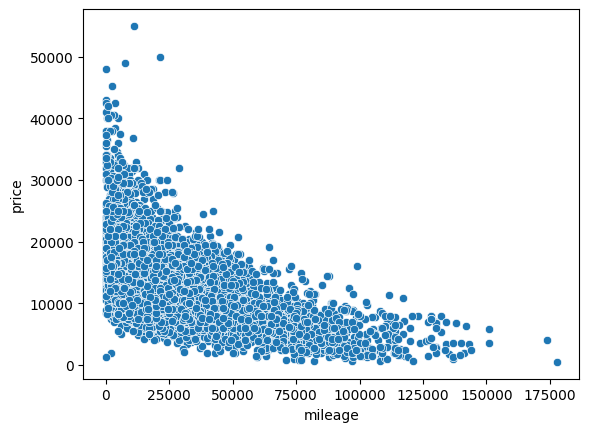

In [13]:
sn.scatterplot( df, x = 'mileage' , y = 'price' )

In [14]:
fig  = px.scatter(df , x = 'mileage' , y  = 'year' )
fig.update_layout(template='plotly_dark')
fig.show()

In [15]:
fig = go.Figure(data = [
      go.Scatter3d(
          x = df['mileage'],
          y = df['year'],
          z = df['price'],
          mode = 'markers',
          marker =dict(
              size = 6,
              color = df['price'],
              colorscale='Viridis',
              opacity=0.8
          )
      )
])
fig.update_layout(template = 'plotly_dark')
fig.show()

<Axes: xlabel='engineSize', ylabel='price'>

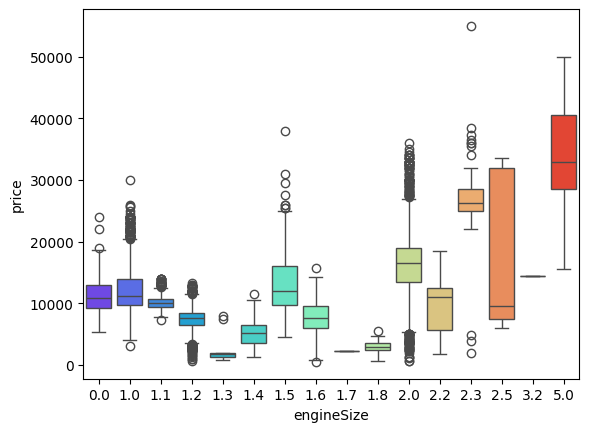

In [16]:
sn.boxplot(data = df,x = 'engineSize', y = 'price' , palette = 'rainbow')

<Axes: xlabel='transmission', ylabel='model'>

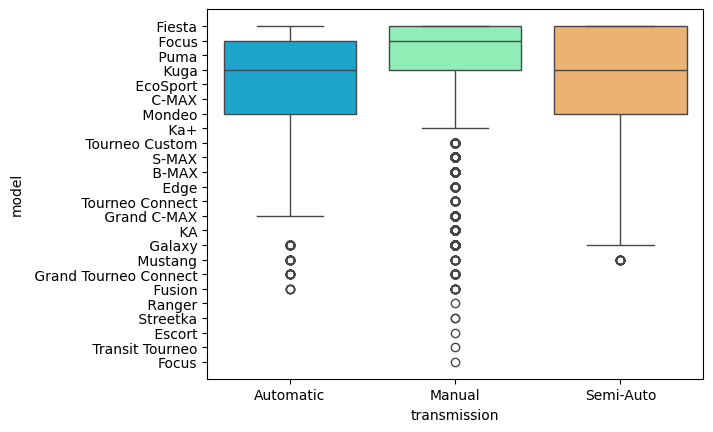

In [17]:
sn.boxplot(df , x = 'transmission', y = 'model' , palette = 'rainbow')

<Axes: xlabel='transmission', ylabel='price'>

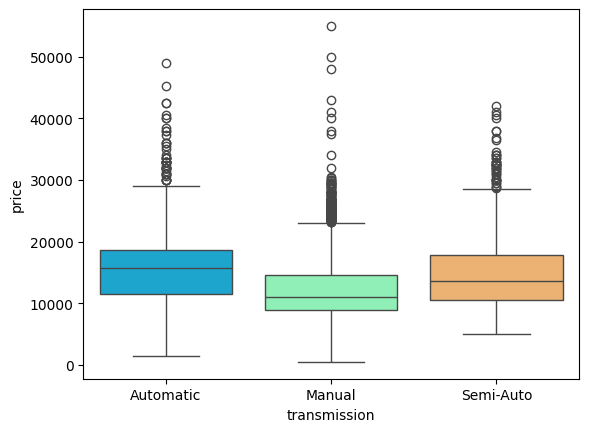

In [18]:
sn.boxplot(df , x = 'transmission', y = 'price' , palette = 'rainbow')

<Axes: xlabel='fuelType', ylabel='price'>

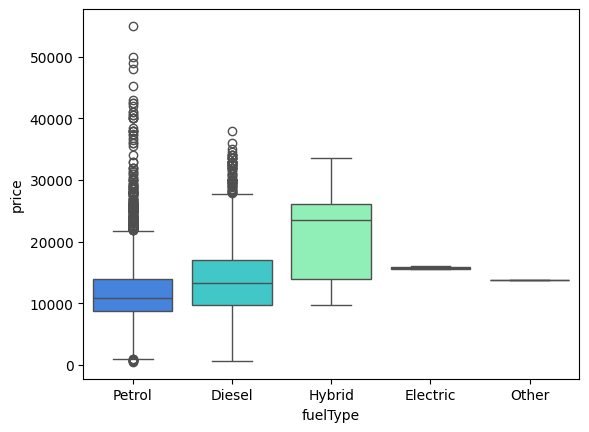

In [19]:
sn.boxplot(df , x = 'fuelType', y = 'price' , palette = 'rainbow')

<Axes: xlabel='price', ylabel='model'>

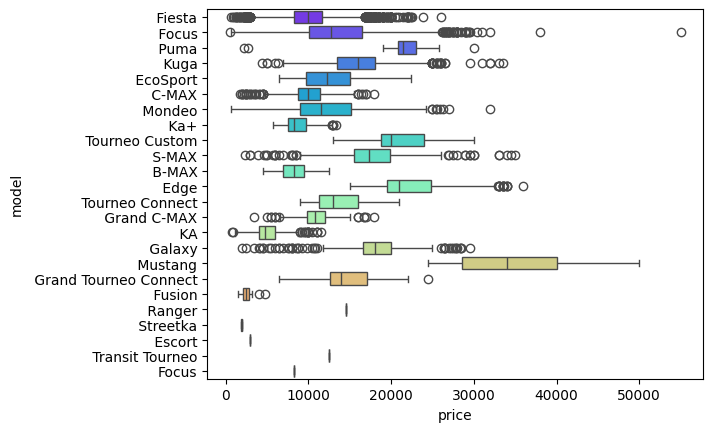

In [20]:
sn.boxplot( y = df['model'], x = df['price'] , palette = 'rainbow')
# plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, '0'),
  Text(1, 0, '20'),
  Text(2, 0, '22'),
  Text(3, 0, '30'),
  Text(4, 0, '110'),
  Text(5, 0, '115'),
  Text(6, 0, '120'),
  Text(7, 0, '125'),
  Text(8, 0, '135'),
  Text(9, 0, '140'),
  Text(10, 0, '145'),
  Text(11, 0, '150'),
  Text(12, 0, '155'),
  Text(13, 0, '160'),
  Text(14, 0, '165'),
  Text(15, 0, '185'),
  Text(16, 0, '190'),
  Text(17, 0, '195'),
  Text(18, 0, '200'),
  Text(19, 0, '205'),
  Text(20, 0, '210'),
  Text(21, 0, '220'),
  Text(22, 0, '230'),
  Text(23, 0, '235'),
  Text(24, 0, '240'),
  Text(25, 0, '260'),
  Text(26, 0, '265'),
  Text(27, 0, '270'),
  Text(28, 0, '290'),
  Text(29, 0, '300'),
  Text(30, 0, '305'),
  Text(31, 0, '325'),
  Text(32, 0, '330'),
  Text(33, 0, '555'),
  Text(34, 0, '570'),
  Text(35, 0, '580')])

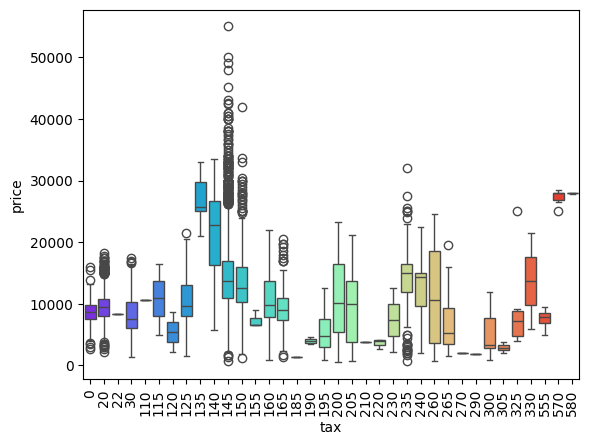

In [21]:
sn.boxplot(x = df['tax'] , y = df['price'], palette= 'rainbow') 
plt.xticks(rotation = 90)

In [22]:
df['price_bins'] = pd.cut(df['price'] , bins = 5)

([0, 1, 2, 3, 4],
 [Text(0, 0, '(440.5, 11395.0]'),
  Text(1, 0, '(11395.0, 22295.0]'),
  Text(2, 0, '(22295.0, 33195.0]'),
  Text(3, 0, '(33195.0, 44095.0]'),
  Text(4, 0, '(44095.0, 54995.0]')])

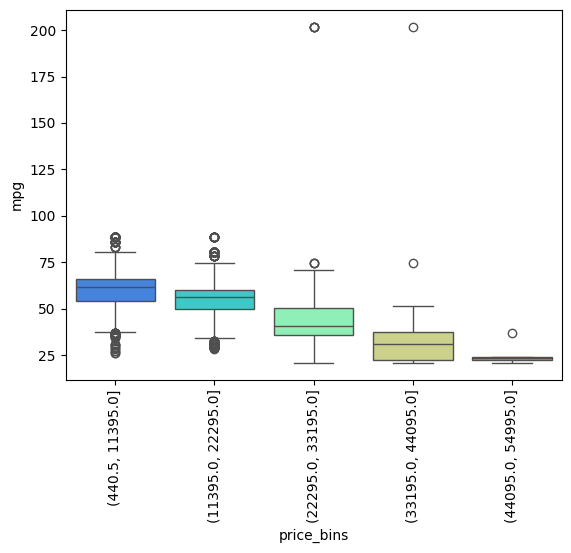

In [23]:
sn.boxplot(data = df,  x = 'price_bins' , y = 'mpg', palette= 'rainbow')
plt.xticks(rotation = 90)

In [24]:
df['price_bin'] = pd.cut(df['price'], bins=5, labels=False)

In [25]:
X = df.drop(columns = ['price'], axis = 1)
y = df['price']
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price_bins,price_bin
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0,"(11395.0, 22295.0]",1
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0,"(11395.0, 22295.0]",1
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0,"(11395.0, 22295.0]",1
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5,"(11395.0, 22295.0]",1
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0,"(11395.0, 22295.0]",1
...,...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4,"(440.5, 11395.0]",0
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0,"(440.5, 11395.0]",0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6,"(440.5, 11395.0]",0
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2,"(440.5, 11395.0]",0


# ONE HOT ENCODING

> 0 and 1 only
* That’s one-hot encoding -> no order, multiple columns

In [26]:
# converting to object to numeric values 
# one hot encoding

X_one_encoded = pd.get_dummies(X , columns = ['model' , 'transmission' , 'fuelType'] , drop_first = True , dtype = int)
X_one_encoded

,year,mileage,tax,mpg,engineSize,price_bins,price_bin,model_ C-MAX,model_ EcoSport,model_ Edge,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57.7,1.0,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40.3,1.5,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48.7,1.0,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,"(440.5, 11395.0]",0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57.7,1.0,"(440.5, 11395.0]",0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67.3,1.6,"(440.5, 11395.0]",0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57.7,1.2,"(440.5, 11395.0]",0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [27]:
X_one_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   year                          17966 non-null  int64   
 1   mileage                       17966 non-null  int64   
 2   tax                           17966 non-null  int64   
 3   mpg                           17966 non-null  float64 
 4   engineSize                    17966 non-null  float64 
 5   price_bins                    17966 non-null  category
 6   price_bin                     17966 non-null  int64   
 7   model_ C-MAX                  17966 non-null  int64   
 8   model_ EcoSport               17966 non-null  int64   
 9   model_ Edge                   17966 non-null  int64   
 10  model_ Escort                 17966 non-null  int64   
 11  model_ Fiesta                 17966 non-null  int64   
 12  model_ Focus                  17966 non-null  

# LABEL ENCODING
> Label Encoding converts categorical data into a single column of integers, where each unique category is assigned a number.
* Label encoding?
→ Uses 0, 1, 2, 3… (depends on number of categories) -> order-based, single column

In [28]:
from sklearn.preprocessing import LabelEncoder

columns = ['model' , 'transmission' , 'fuelType']
Xlabel = X.copy()

label_encoders = {}

for i in columns :
    le = LabelEncoder()
    Xlabel[i] = le.fit_transform(Xlabel[i].astype(str)) # fit_transform -> learn rules + apply rules 
    label_encoders[i] = le

In [29]:
Xlabel['model'].value_counts()

model
5     6557
6     4588
13    2225
2     1143
1      543
12     531
14     526
0      355
18     296
9      247
8      228
3      208
11     199
16      80
21      69
10      59
15      57
20      33
7       16
19       2
17       1
4        1
22       1
23       1
Name: count, dtype: int64

In [30]:
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price_bins,price_bin
0,5,2017,0,15944,4,150,57.7,1.0,"(11395.0, 22295.0]",1
1,6,2018,1,9083,4,150,57.7,1.0,"(11395.0, 22295.0]",1
2,6,2017,1,12456,4,150,57.7,1.0,"(11395.0, 22295.0]",1
3,5,2019,1,10460,4,145,40.3,1.5,"(11395.0, 22295.0]",1
4,5,2019,0,1482,4,145,48.7,1.0,"(11395.0, 22295.0]",1
...,...,...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4,"(440.5, 11395.0]",0
17962,0,2014,1,40700,4,30,57.7,1.0,"(440.5, 11395.0]",0
17963,6,2015,1,7010,0,20,67.3,1.6,"(440.5, 11395.0]",0
17964,11,2018,1,5007,4,145,57.7,1.2,"(440.5, 11395.0]",0


In [31]:
from sklearn.preprocessing import LabelEncoder

columns = ['model', 'transmission', 'fuelType']
Xlabel = X.copy()

label_encoders = {}

for i in columns:
    le = LabelEncoder()
    Xlabel[i] = le.fit_transform(Xlabel[i].astype(str))  # ✅ correct
    label_encoders[i] = le

In [32]:
X['model'].value_counts(dropna=False)

model
 Fiesta                   6557
 Focus                    4588
 Kuga                     2225
 EcoSport                 1143
 C-MAX                     543
 Ka+                       531
 Mondeo                    526
 B-MAX                     355
 S-MAX                     296
 Grand C-MAX               247
 Galaxy                    228
 Edge                      208
 KA                        199
 Puma                       80
 Tourneo Custom             69
 Grand Tourneo Connect      59
 Mustang                    57
 Tourneo Connect            33
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

In [33]:
X = pd.read_csv("/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")   # reload fresh data
Xlabel = X.copy()

In [34]:
from sklearn.preprocessing import LabelEncoder

columns = ['model', 'transmission', 'fuelType']
label_encoders = {}

for col in columns:
    le = LabelEncoder()
    Xlabel[col] = le.fit_transform(Xlabel[col].astype(str))  # ✅ correct
    label_encoders[col] = le

In [35]:
print(X['model'].head())
print(X['model'].nunique())

0     Fiesta
1      Focus
2      Focus
3     Fiesta
4     Fiesta
Name: model, dtype: object
24


In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['model_encoded'] = le.fit_transform(X['model'])

In [37]:
print(X[['model', 'model_encoded']].head())

     model  model_encoded
0   Fiesta              5
1    Focus              6
2    Focus              6
3   Fiesta              5
4   Fiesta              5


In [38]:
X_backup = X.copy()

# Standard Scaler
> StandardScaler is a technique used to scale numerical features so that they have:

1. Mean = 0
2. Standard Deviation = 1

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
numeric_cols = ['year' , 'mileage' , 'tax' , 'mpg', 'engineSize']
scaler = StandardScaler()

X_one_encoded[numeric_cols] = scaler.fit_transform(X_one_encoded[numeric_cols])

In [41]:
X_one_encoded

,year,mileage,tax,mpg,engineSize,price_bins,price_bin,model_ C-MAX,model_ EcoSport,model_ Edge,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,"(11395.0, 22295.0]",1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.067312,0.113779,"(440.5, 11395.0]",0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.020442,-0.811386,"(440.5, 11395.0]",0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.927668,0.576362,"(440.5, 11395.0]",0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.020442,-0.348804,"(440.5, 11395.0]",0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [42]:
Xlabel.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [43]:
Xlabel[['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize']] = scaler.fit_transform(Xlabel[['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize']])
Xlabel

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-0.058959,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.362875,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.151958,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,1.101082,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,0.890166,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,-0.691919,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,-1.008294,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,-0.481003,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,-0.839561,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encoded , y, test_size=0.33, random_state=42)

In [46]:
print(X_train.dtypes)

year                             float64
mileage                          float64
tax                              float64
mpg                              float64
engineSize                       float64
price_bins                      category
price_bin                          int64
model_ C-MAX                       int64
model_ EcoSport                    int64
model_ Edge                        int64
model_ Escort                      int64
model_ Fiesta                      int64
model_ Focus                       int64
model_ Fusion                      int64
model_ Galaxy                      int64
model_ Grand C-MAX                 int64
model_ Grand Tourneo Connect       int64
model_ KA                          int64
model_ Ka+                         int64
model_ Kuga                        int64
model_ Mondeo                      int64
model_ Mustang                     int64
model_ Puma                        int64
model_ Ranger                      int64
model_ S-MAX    

In [47]:
X['price_bin'] = pd.cut(X['price'], bins=5, labels=False)

In [48]:
bad_cols = X_train.select_dtypes(include=['object', 'category']).columns
print("Problem columns:", bad_cols)

Problem columns: Index(['price_bins'], dtype='object')


In [49]:
for col in bad_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [50]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [51]:
model= LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [52]:
y_pred = model.predict(X_test)
y_pred

array([ 7119.6472404 ,  8707.68592637,  8983.86665283, ...,
       18702.57613557,  5958.00096743,  9363.06935104])

In [53]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [54]:
r2 = r2_score(y_test, y_pred)
r2

0.9147554248069706

In [55]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1-r2) * (n - 1))/(n - p - 1)
print('Adjusted R2 Score ' , adjusted_r2)

Adjusted R2 Score  0.9141908911964207


# FOR ONE HOT ENCODING

In [56]:
X_train, X_test, y_train, y_test = train_test_split(Xlabel , y, test_size=0.33, random_state=42)

In [57]:
model_2= LinearRegression()
model_2.fit(X_train,y_train)

LinearRegression()

In [58]:
y_pred = model_2.predict(X_test)
y_pred

array([ 6995.,  8999.,  7998., ..., 21999.,  6995., 10299.])

In [59]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [60]:
r2 = r2_score(y_test, y_pred)
r2

1.0

In [61]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1-r2) * (n - 1))/(n - p - 1)
print('Adjusted R2 Score ' , adjusted_r2)

Adjusted R2 Score  1.0
